# Deep Learning for NLP

**Deep Learning** is a type of Machine Learning that uses **Neural Networks with multiple layers** to learn patterns from data.

Deep Learning can be used in NLP tasks such as:
- Text Classification
- Sentiment Analysis
- Question Answering

In this lab, we will build a **deep learning model** to classify Yelp restaurant reviews as:

- **0 = Negative**
- **1 = Positive**

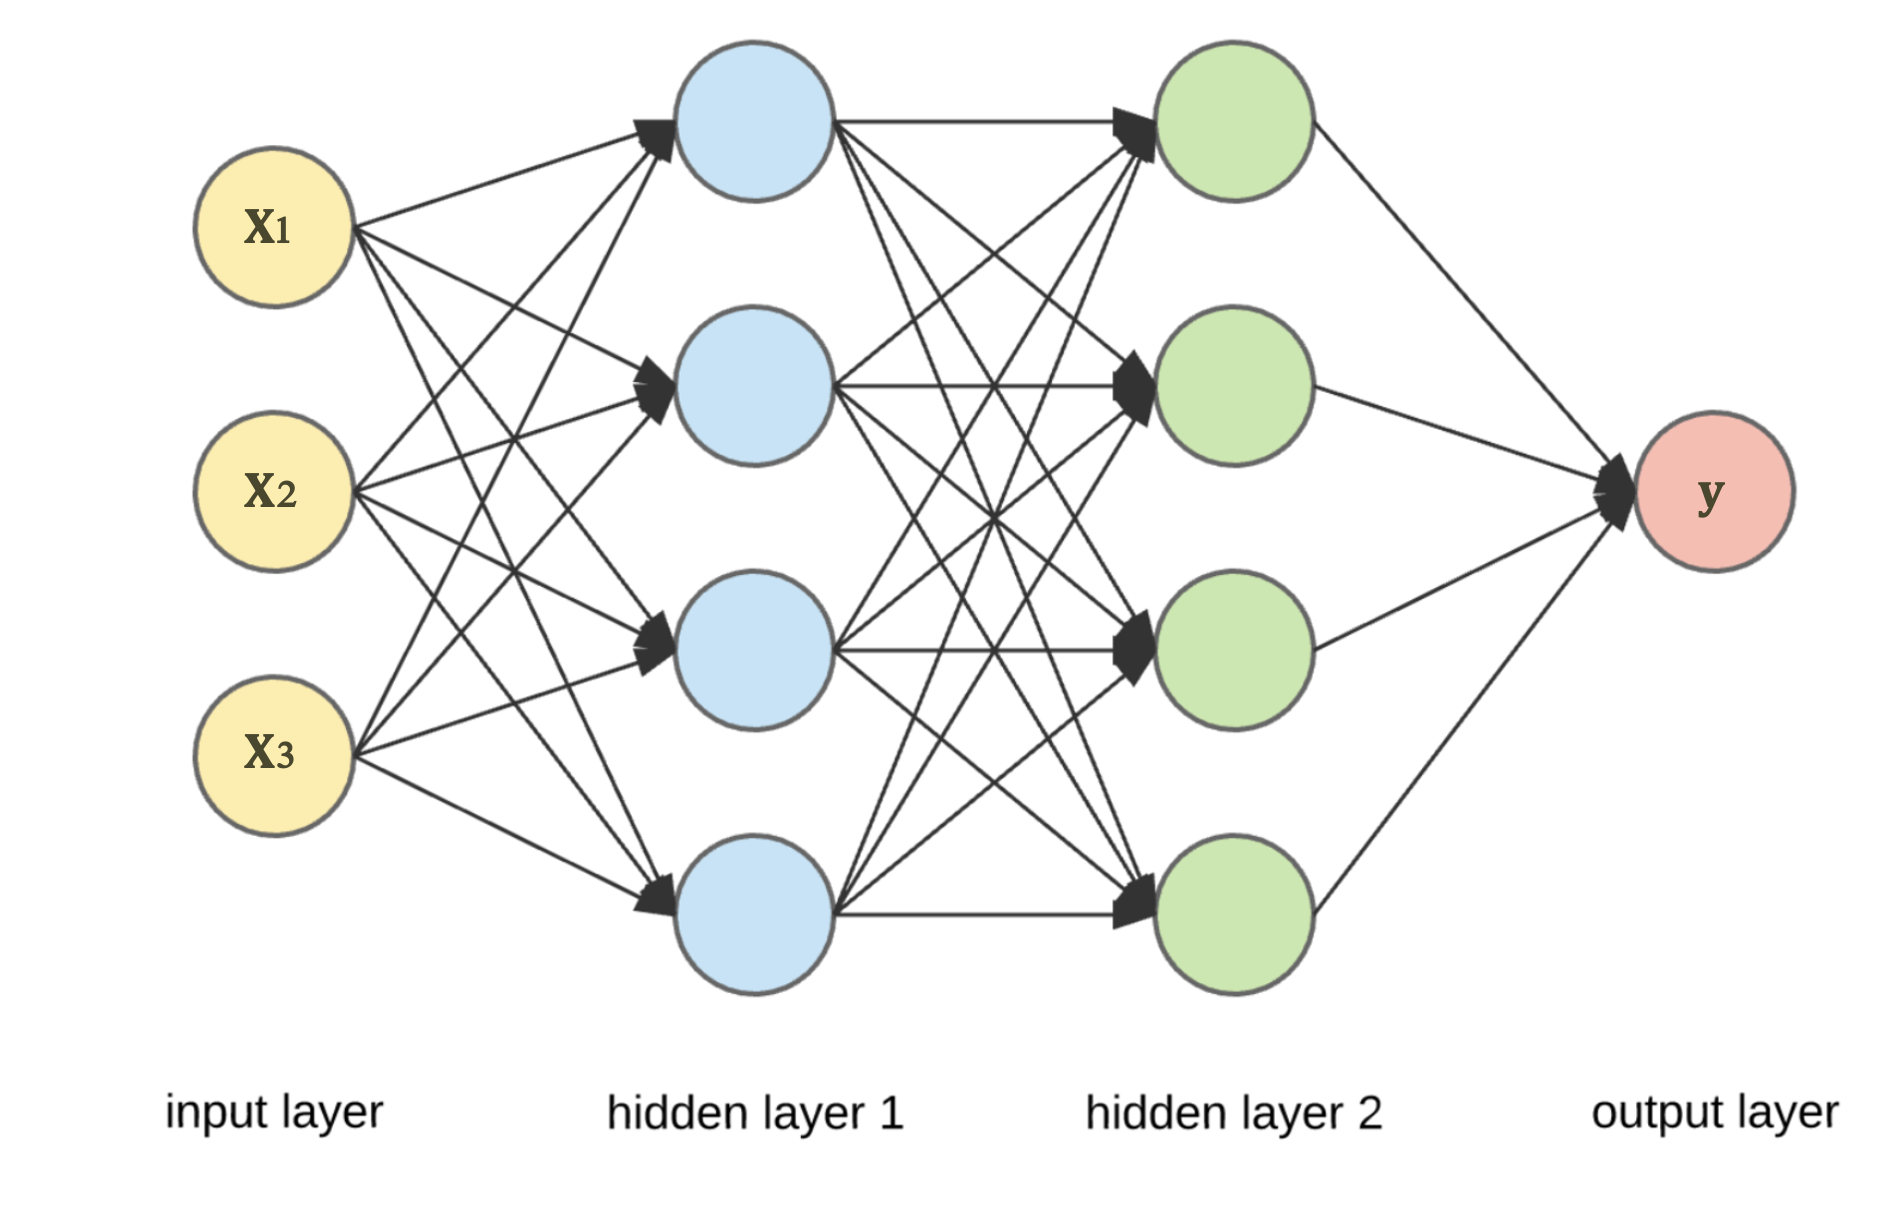
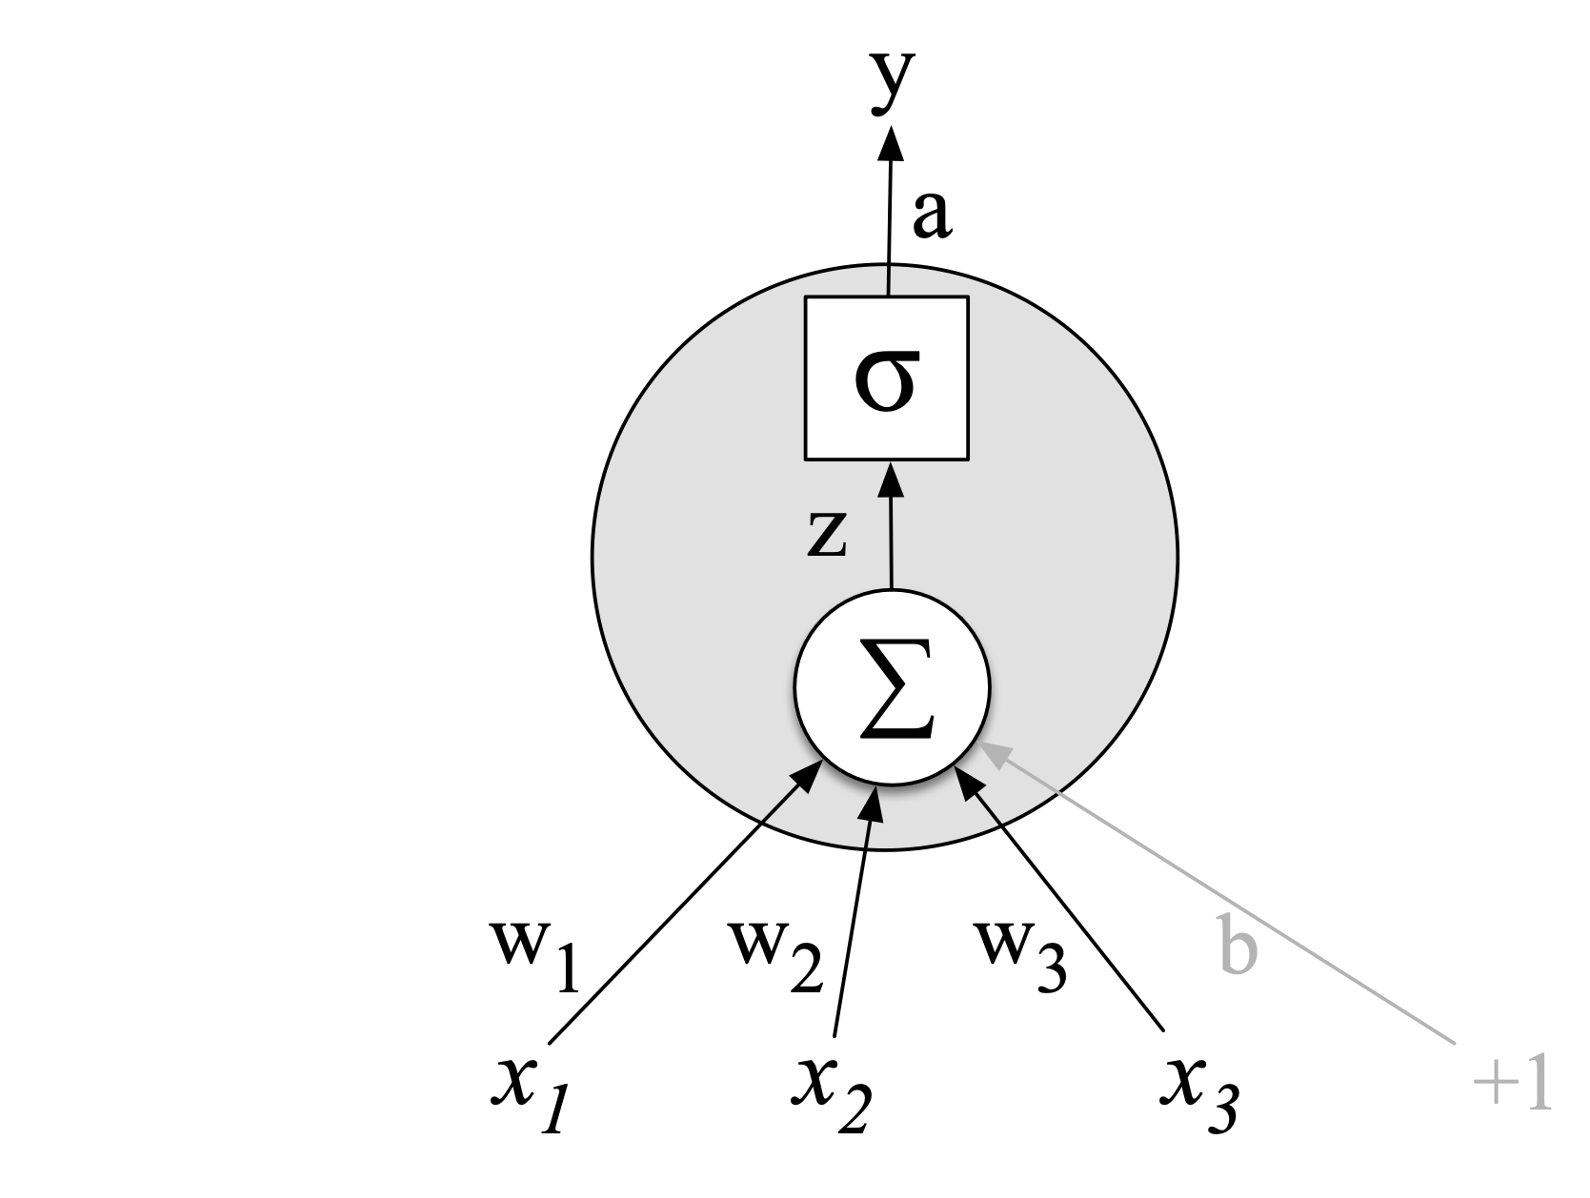

## 1. Load the Yelp Dataset

Each row contains:

- a restaurant review
- its sentiment label


In [1]:
import pandas as pd

df = pd.read_csv("07-yelp-dataset.txt", sep="\t", names=["review", "label"])

print("Number of reviews:", len(df))
df.head()

Number of reviews: 1000


,review,label
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [2]:
print(df["label"].value_counts())

label
1    500
0    500
Name: count, dtype: int64


## 2. Preprocessing the Dataset

In [3]:
import re

def preprocess_text(text):

    # 1. Convert to lowercase
    text = text.lower()

    # 2. Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # 3. Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

    df["review"] = df["review"].apply(preprocess_text)
    df.head()

## 3. Split the Data

We divide the dataset into:

- **80% training data** — used to train the model
- **20% testing data** — used to evaluate the model

`stratify=y` keeps the proportion of positive and negative reviews similar in both sets.

In [4]:
from sklearn.model_selection import train_test_split

X = df["review"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Training reviews:", len(X_train))
print("Testing reviews:", len(X_test))

Training reviews: 800
Testing reviews: 200


## 4. Convert Text to TF-IDF Vectors

A neural network cannot directly understand text.

**TF-IDF converts each review into a vector of numbers.**


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=1000, lowercase=True)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (800, 1000)
Testing TF-IDF shape: (200, 1000)


## 5. Convert the Data to PyTorch Tensors

PyTorch neural networks work with **tensors**.

In [6]:
import torch
import torch.nn as nn

# Convert TF-IDF data to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_tfidf.toarray())
X_test_tensor = torch.FloatTensor(X_test_tfidf.toarray())

y_train_tensor = torch.FloatTensor(y_train.values).reshape(-1, 1)

/tmp/ipykernel_519/803754565.py:8: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  y_train_tensor = torch.FloatTensor(y_train.values).reshape(-1, 1)


## 6. Build a Simple Neural Network

Our network has:

1. **Input layer** — receives the TF-IDF features
2. **Hidden layer** — learns useful patterns
3. **ReLU activation** — adds non-linearity
4. **Output layer** — produces one value for binary classification

We do **not** put `Sigmoid` inside the model because `BCEWithLogitsLoss` applies it internally in a numerically stable way.

In [7]:
input_size = X_train_tensor.shape[1]
# torch.size([800, 1000])

model = nn.Sequential(
    nn.Linear(input_size, 64),   # Input layer
    nn.ReLU(),

    nn.Linear(64, 32),           # Hidden layer
    nn.ReLU(),

    nn.Linear(32, 1)             # Output layer
)

print(model)

Sequential(
  (0): Linear(in_features=1000, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=1, bias=True)
)


## 7. Choose the Loss Function and Optimizer

- **BCEWithLogitsLoss** is used for binary classification.
To measure the model’s mistakes.
- **Adam** is responsible for changing the model's weights so that the loss becomes smaller.

In [8]:
loss_function = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

## 8. Train the Neural Network

One **epoch** means the model has seen the full training dataset once.

For every epoch:

1. Make predictions
2. Calculate the loss
3. Calculate gradients with backpropagation
4. Update the weights

In [9]:
epochs = 10

for epoch in range(epochs):
    model.train()

    # 1. Forward pass
    outputs = model(X_train_tensor)

    # 2. Calculate loss
    loss = loss_function(outputs, y_train_tensor)

    # 3. Backpropagation
    loss.backward()

    # 4. Update model weights
    optimizer.step()

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch + 1}/{epochs} - Loss: {loss.item():.4f}")

Epoch 5/10 - Loss: 0.6512
Epoch 10/10 - Loss: 0.4720


## 9. Evaluate the Model

The model outputs raw scores called **logits**.

We apply `sigmoid` to convert them to probabilities between 0 and 1.

- Probability **≥ 0.5 → Positive (1)**
- Probability **< 0.5 → Negative (0)**

In [10]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model.eval()

with torch.no_grad():
    test = model(X_test_tensor)
    test_probabilities = torch.sigmoid(test)
    predictions = (test_probabilities >= 0.5).int().numpy().flatten()

accuracy = accuracy_score(y_test, predictions)

print(f"Test Accuracy: {accuracy:.3f}")

Test Accuracy: 0.695


## 10. Classification Report and Confusion Matrix

The classification report shows:

- **Precision**
- **Recall**
- **F1-score**

The confusion matrix shows how many reviews were classified correctly and incorrectly.

In [11]:
print("Classification Report:")
print(classification_report(y_test, predictions, target_names=["Negative", "Positive"]))

print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions))

Classification Report:
              precision    recall  f1-score   support

    Negative       0.67      0.72      0.69        96
    Positive       0.72      0.67      0.70       104

    accuracy                           0.69       200
   macro avg       0.70      0.70      0.69       200
weighted avg       0.70      0.69      0.70       200

Confusion Matrix:
[[69 27]
 [34 70]]


## Task 1 – Represent Reviews Using Word2Vec

In the previous part of the lab, TF-IDF was used to convert each review into numerical features.
Now, use Word2Vec instead.

Requirements:
Tokenize the training and testing reviews.
Train a Word2Vec model using the training reviews.
Use:
vector_size = 200
window = 5
min_count = 1
sg = 1

Convert each review into a single vector.
Convert the resulting vectors into PyTorch tensors.


In [12]:
import numpy as np
import gensim

# 1. Tokenize the training and testing reviews
train_tokens = [preprocess_text(review).split() for review in X_train]
test_tokens = [preprocess_text(review).split() for review in X_test]

print(train_tokens[:3])

[['the', 'worst', 'was', 'the', 'salmon', 'sashimi'], ['an', 'excellent', 'new', 'restaurant', 'by', 'an', 'experienced', 'frenchman'], ['went', 'for', 'lunch', 'service', 'was', 'slow']]


In [13]:
# 2. Train a Word2Vec model using the training reviews
w2v_model = gensim.models.Word2Vec(train_tokens, vector_size=200, window=5, min_count=1, sg=1)

print("Vocabulary size:", len(w2v_model.wv))

Vocabulary size: 1801


In [14]:
# 3. Convert each review into a single vector (the average of its word vectors)
def review_to_vector(tokens, model, vector_size=200):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

X_train_w2v = np.array([review_to_vector(tokens, w2v_model) for tokens in train_tokens])
X_test_w2v = np.array([review_to_vector(tokens, w2v_model) for tokens in test_tokens])

print("Training Word2Vec shape:", X_train_w2v.shape)
print("Testing Word2Vec shape:", X_test_w2v.shape)

Training Word2Vec shape: (800, 200)
Testing Word2Vec shape: (200, 200)


In [15]:
# 4. Convert the vectors into PyTorch tensors
X_train_w2v_tensor = torch.FloatTensor(X_train_w2v)
X_test_w2v_tensor = torch.FloatTensor(X_test_w2v)

y_train_w2v_tensor = torch.FloatTensor(y_train.values).reshape(-1, 1)

print("X_train tensor:", X_train_w2v_tensor.shape)
print("X_test tensor:", X_test_w2v_tensor.shape)
print("y_train tensor:", y_train_w2v_tensor.shape)

X_train tensor: torch.Size([800, 200])
X_test tensor: torch.Size([200, 200])
y_train tensor: torch.Size([800, 1])


## Task 2 – Build a Different Neural Network

Use the Word2Vec vectors from Task 1 as the input to a new neural network.
Your network must contain:
An input layer
Three hidden layers
ReLU activation functions
One output neuron
Use the following architecture:

Input
   
   ↓

128 neurons
   
   ↓

64 neurons
   
   ↓

32 neurons
   
   ↓

1 output neuron

Train the model using:
, BCEWithLogitsLoss
, Adam optimizer
, Learning rate = 0.001
, 15 epochs.
Then calculate the test accuracy.

In [16]:
w2v_input_size = X_train_w2v_tensor.shape[1]

w2v_nn_model = nn.Sequential(
    nn.Linear(w2v_input_size, 128),   # Input layer -> Hidden layer 1
    nn.ReLU(),

    nn.Linear(128, 64),               # Hidden layer 2
    nn.ReLU(),

    nn.Linear(64, 32),                # Hidden layer 3
    nn.ReLU(),

    nn.Linear(32, 1)                  # Output layer
)

print(w2v_nn_model)

Sequential(
  (0): Linear(in_features=200, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=32, bias=True)
  (5): ReLU()
  (6): Linear(in_features=32, out_features=1, bias=True)
)


In [17]:
loss_function_w2v = nn.BCEWithLogitsLoss()
optimizer_w2v = torch.optim.Adam(w2v_nn_model.parameters(), lr=0.001)

In [18]:
epochs = 15

for epoch in range(epochs):
    w2v_nn_model.train()

    # 1. Forward pass
    outputs = w2v_nn_model(X_train_w2v_tensor)

    # 2. Calculate loss
    loss = loss_function_w2v(outputs, y_train_w2v_tensor)

    # 3. Backpropagation
    optimizer_w2v.zero_grad()
    loss.backward()

    # 4. Update model weights
    optimizer_w2v.step()

    print(f"Epoch {epoch + 1}/{epochs} - Loss: {loss.item():.4f}")

Epoch 1/15 - Loss: 0.6932
Epoch 2/15 - Loss: 0.6931
Epoch 3/15 - Loss: 0.6931
Epoch 4/15 - Loss: 0.6931
Epoch 5/15 - Loss: 0.6931
Epoch 6/15 - Loss: 0.6931
Epoch 7/15 - Loss: 0.6931
Epoch 8/15 - Loss: 0.6931


Epoch 9/15 - Loss: 0.6931
Epoch 10/15 - Loss: 0.6931
Epoch 11/15 - Loss: 0.6930
Epoch 12/15 - Loss: 0.6930
Epoch 13/15 - Loss: 0.6930
Epoch 14/15 - Loss: 0.6930
Epoch 15/15 - Loss: 0.6930


In [19]:
w2v_nn_model.eval()

with torch.no_grad():
    test_outputs = w2v_nn_model(X_test_w2v_tensor)
    test_probabilities = torch.sigmoid(test_outputs)
    w2v_predictions = (test_probabilities >= 0.5).int().numpy().flatten()

w2v_accuracy = accuracy_score(y_test, w2v_predictions)

print(f"Test Accuracy (Word2Vec): {w2v_accuracy:.3f}")

Test Accuracy (Word2Vec): 0.480


# What I Learned

In this lab I built my first neural network for text classification using PyTorch. I learned that the network itself is not complicated: it is just a few Linear layers with ReLU between them, and the last layer gives one number (a logit) that goes through sigmoid to become a probability. What surprised me is how much the result depends on how the text is turned into numbers before it goes into the network.

With TF-IDF, the simple network from the lab reached around 70% to 75% accuracy on the test set (the number changed a little each time I ran it). In Task 1, I replaced TF-IDF with Word2Vec. I tokenized the reviews, trained a skip-gram model on the training reviews only, and then turned every review into one vector by taking the average of its word vectors. If a test review had words that were not in the vocabulary, I skipped them, and if no words were found I used a vector of zeros. Then I converted everything into tensors so the network can use them.

In Task 2, I built a deeper network (128, 64 and 32 neurons) and trained it for 15 epochs with a learning rate of 0.001. The result was not what I expected. The loss stayed at about 0.693 the whole time and the test accuracy was around 50%, which means the model was basically guessing. At first I thought something was wrong with my code, but after thinking about it I understood the reasons:

- The Word2Vec model was trained on only 800 short reviews. This is too little data for it to learn good word meanings, so the vectors of "good" and "bad" words end up very close to each other.
- Taking the average of all the words in a review makes the important words (like "loved" or "not") lose their effect, because common words like "the" and "was" are mixed in with them.
- With full batch training, 15 epochs means only 15 weight updates, and with a small learning rate like 0.001 that is not enough for the model to move away from 0.693.

So a deeper network does not automatically mean better results. If the input features are weak, adding more layers will not fix it. Word2Vec usually works much better when it is trained on a big corpus or when we use pre-trained vectors.

I also learned that in PyTorch you need to call optimizer.zero_grad() before loss.backward() in every epoch, because the gradients add up by default. If you don't reset them, each update uses the gradients from all the previous epochs too.